<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/%D7%9E%D7%98%D7%9C%D7%94_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **מטלה 4**
## חקירת דאטה שמיוצר על ידי בינה מלאכותית

**מגיש:** אלון ספיר
**תעודת זהות:** 214316762
**מרצה:** שי גול

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [4]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Matrix of:",df.shape)


df.head()

Saving chess_dataset.csv to chess_dataset (1).csv
Matrix of: (3000, 15)


,player_id,age,years_of_experience,region,family_chess_background,has_chess_coach,hours_studied_per_week,tournaments_played_last_year,preferred_time_control,primary_opening_style,tactics_puzzle_rating,tilt_factor,chess_events_il_premium_tier,estimated_elo,win_vs_club_player_1500
0,1001,NaN,39.0,Asia,0.0,0.0,0.0,4.0,Rapid,Positional,2174.0,0.69,Free,2037.0,1.0
1,1002,24.0,NaN,Americas,1.0,0.0,0.4,1.0,Classical,Positional,1001.0,NaN,Free,985.0,0.0
2,1003,70.0,23.0,NaN,1.0,1.0,11.6,7.0,Rapid,Positional,2002.0,0.37,Free,1798.0,1.0
3,1004,30.0,23.0,East Europe & Russia,0.0,0.0,7.9,3.0,Bullet,Defensive,2211.0,0.21,Pro,2006.0,1.0
4,1005,33.0,9.0,Americas,0.0,0.0,0.0,2.0,Rapid,Aggressive,1289.0,0.25,NaN,1030.0,0.0


# **השוואת ביצועים בין מודלי סיווג שונים**

בשלב זה נבצע הערכה השוואתית בין מספר אלגוריתמים של למידת מכונה, כדי לזהות איזה מודל מספק את יכולת החיזוי הטובה ביותר עבור הנתונים שלנו (חיזוי ניצחונות מול שחקן ברמת מועדון).

### **מודלים הנבחנים בהשוואה:**
* **Random Forest:** מודל אנסמבל המשלב מספר רב של עצי החלטה. חסין יחסית לרעשים ולתופעת Overfitting.
* **Decision Trees (Information Gain & Gini):** עצי החלטה בודדים המשתמשים בקריטריונים שונים לפיצול הצמתים.
* **Perceptron:** מודל לינארי בסיסי, אבן הבניין של רשתות נוירונים.
* **KNN (K-Nearest Neighbors):** אלגוריתם מבוסס מרחק שמתייג דגימות לפי השכנים הקרובים אליהן ביותר.
* **Gaussian Naive Bayes:** מודל הסתברותי המניח אי-תלות בין המאפיינים והתפלגות נורמלית.

### **שלבי הביצוע בקוד:**
1. **עיבוד מקדים מתקדם (Preprocessing):** אלגוריתמים כמו KNN ו-Perceptron רגישים מאוד להבדלי סדרי גודל בנתונים (למשל, בין גיל לשעות לימוד בשבוע). לכן, הוספנו תהליך נרמול (`StandardScaler`) לעמודות הנומריות, לצד קידוד (`OneHotEncoder`) לעמודות הקטגוריאליות.
2. **אימון אוטומטי (Training):** הקוד רץ בלולאה על כל המודלים, בונה עבור כל אחד `Pipeline` נפרד, מאמן אותו על נתוני האימון ובוחן אותו על נתוני הבדיקה.
3. **ויזואליזציה:** לבסוף, מופק גרף עמודות ממוין המציג את ציון הדיוק (Accuracy) של כל מודל, מה שמאפשר השוואה חזותית וברורה של הביצועים.

Training and evaluating models...

Random Forest: Accuracy = 0.790
Decision Tree (Info Gain): Accuracy = 0.737
Decision Tree (Gini): Accuracy = 0.750
Perceptron: Accuracy = 0.754
KNN: Accuracy = 0.739
Gaussian Naive Bayes: Accuracy = 0.764


/tmp/ipykernel_5829/3628147754.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(results_sorted.keys()), y=list(results_sorted.values()), palette='viridis')


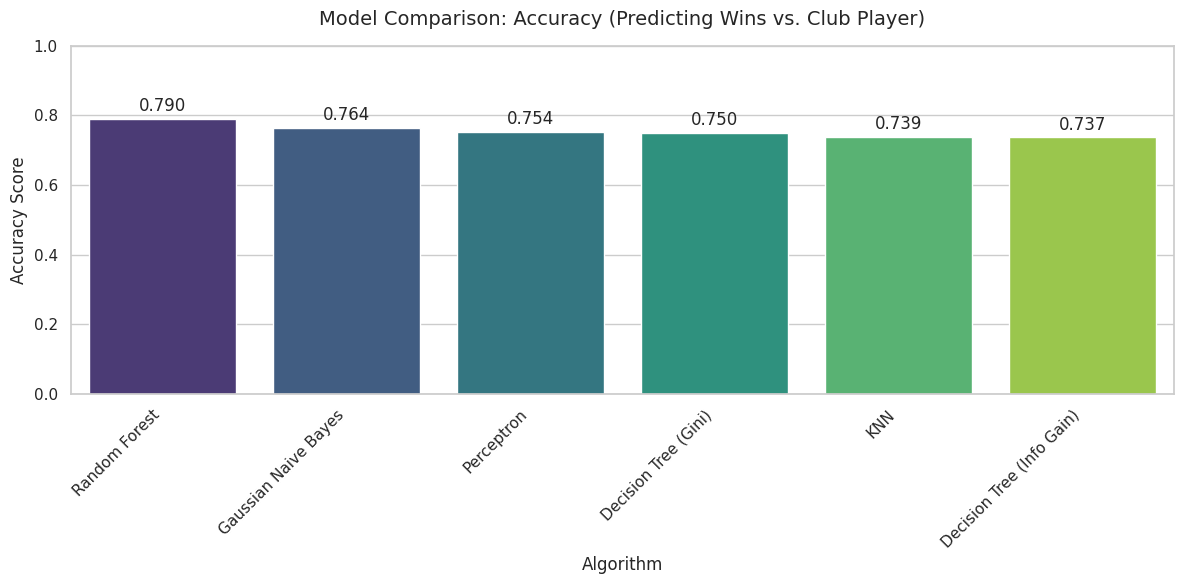

In [7]:
# 1. ניקוי ראשוני והפרדה בין X ל-y
target = 'win_vs_club_player_1500'
df_clean = df.dropna(subset=[target]).copy()

X = df_clean.drop(columns=['player_id', target, 'estimated_elo'])
y = df_clean[target]

# 2. חלוקה לסוגי עמודות
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 3. צינור עיבוד נתונים - הוספנו StandardScaler שעוזר מאוד למודלים כמו KNN ו-Perceptron
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# sparse_output=False חשוב כדי ש-Gaussian Naive Bayes יוכל לקבל את הנתונים
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. הגדרת המילון של כל המודלים לבדיקה
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree (Info Gain)': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Decision Tree (Gini)': DecisionTreeClassifier(criterion='gini', random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB()
}

# 5. חלוקה לאימון ובדיקה
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. אימון כל המודלים ושמירת התוצאות
results = {}
print("Training and evaluating models...\n")

for name, model_cls in models.items():
    # בניית פייפליין ייעודי לכל מודל
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_cls)
    ])

    # אימון ופרדיקציה
    clf_pipeline.fit(X_train, y_train)
    y_pred = clf_pipeline.predict(X_test)

    # חישוב דיוק ושמירה בתוצאות
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.3f}")

# 7. הצגת התוצאות בגרף
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# יצירת גרף עמודות ממוין מהגבוה לנמוך
results_sorted = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
bars = sns.barplot(x=list(results_sorted.keys()), y=list(results_sorted.values()), palette='viridis')

plt.title('Model Comparison: Accuracy (Predicting Wins vs. Club Player)', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.ylim(0, 1) # ציר ה-Y תמיד בין 0 ל-1 באחוזים
plt.xticks(rotation=45, ha='right')

# הוספת התוצאה המספרית מעל כל עמודה
for p in bars.patches:
    bars.annotate(f'{p.get_height():.3f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center',
                  xytext = (0, 9),
                  textcoords = 'offset points')

plt.tight_layout()
plt.show()